# Moving Average Models for Erratic Profile Cluster

This notebook applies **moving average forecasting models** exclusively to time series classified as **erratic** in the `profile_cluster` column.

---

## Rationale

Erratic series are characterized by high coefficient of variation (CV²) with relatively regular demand intervals. Simple moving average models can be effective baselines for these series because:

- They smooth out high-variance fluctuations
- They require no hyperparameter tuning (just window size)
- They provide robust baselines against which ML models can be benchmarked

---

## Models Evaluated

1. **Simple Moving Average (SMA)** — equal-weighted rolling mean
2. **Weighted Moving Average (WMA)** — linearly decreasing weights
3. **Exponential Moving Average (EMA)** — exponentially decaying weights

---

## Metrics Computed

- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **WMAPE** (Weighted Mean Absolute Percentage Error)

# Load Packages

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

%matplotlib inline

print("Packages loaded successfully!")

Packages loaded successfully!


# Configuration

In [ ]:
# Time series configuration
date_var = 'ds'
unique_id = 'STORE_LOCATION_ID'
y = 'TOTAL_NET_SALES'
frequency = 'W-MON'

# Training/forecast dates
training_start_date = '2024-01-01'
training_end_date = '2025-01-06'
forecast_start_date = '2025-01-13'
forecast_end_date = '2025-05-20'

# Moving average windows to evaluate
MA_WINDOWS = [3, 4, 6, 8, 12]

# EMA span parameter
EMA_SPANS = [3, 4, 6, 8, 12]

# Filter for erratic profile_cluster
TARGET_PROFILE_CLUSTER = 'erratic'

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"
FEATURE_TABLE_NAME = "df_features"
PROFILE_CLUSTER_TABLE_NAME = "df_profiling_clustering"
LOCAL_FOLDER = "supermarket_net_sales"

root_path = Path.cwd().parent.parent

print(f"Configuration loaded:")
print(f"  - Target profile_cluster: {TARGET_PROFILE_CLUSTER}")
print(f"  - MA windows: {MA_WINDOWS}")
print(f"  - EMA spans: {EMA_SPANS}")
print(f"  - Training period: {training_start_date} to {training_end_date}")
print(f"  - Forecast period: {forecast_start_date} to {forecast_end_date}")

Configuration loaded:
  - Target profile_cluster: erratic
  - MA windows: [3, 4, 6, 8, 12]
  - EMA spans: [3, 4, 6, 8, 12]
  - Training period: 2024-01-01 to 2025-01-06
  - Forecast period: 2025-01-13 to 2025-05-20


# Load Data

In [3]:
# Load feature data
try:
    df = spark.read.table(f'{LAKEHOUSE_NAME}.{FEATURE_TABLE_NAME}').toPandas()
except:
    print("Failed to load from Lakehouse. Loading from local parquet file.")
    df = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{FEATURE_TABLE_NAME}.parquet")

print(f"Loaded {len(df)} rows")

# Load profiling/clustering data and add profile_cluster if missing
if 'profile_cluster' not in df.columns:
    try:
        df_profile_cluster = spark.read.table(f'{LAKEHOUSE_NAME}.{PROFILE_CLUSTER_TABLE_NAME}').toPandas()
    except:
        print("Failed to load from Lakehouse. Loading from local parquet file.")
        df_profile_cluster = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{PROFILE_CLUSTER_TABLE_NAME}.parquet")

    df = df.merge(df_profile_cluster[['profile_cluster', unique_id]], on=unique_id, how='left')
    print(f"Merged profile_cluster column.")
else:
    print("profile_cluster column already exists.")

df[date_var] = pd.to_datetime(df[date_var])

print(f"\nProfile cluster distribution:")
print(df.drop_duplicates(subset=[unique_id])['profile_cluster'].value_counts())

Failed to load from Lakehouse. Loading from local parquet file.
Loaded 4800 rows
profile_cluster column already exists.

Profile cluster distribution:
profile_cluster
0.0        13
erratic    12
1.0        11
2.0        11
3.0         3
Name: count, dtype: int64


# Filter Erratic Series Only

In [4]:
# Filter to erratic profile_cluster only
df_erratic = df[df['profile_cluster'] == TARGET_PROFILE_CLUSTER].copy()

n_series = df_erratic[unique_id].nunique()
n_rows = len(df_erratic)

print(f"Erratic series: {n_series} unique time series")
print(f"Total rows: {n_rows}")
print(f"Date range: {df_erratic[date_var].min().date()} to {df_erratic[date_var].max().date()}")

if n_series == 0:
    raise ValueError("No series found with profile_cluster == 'erratic'. Check data.")

Erratic series: 12 unique time series
Total rows: 1152
Date range: 2023-05-22 to 2025-03-17


## Visualize Erratic Series (Aggregated)

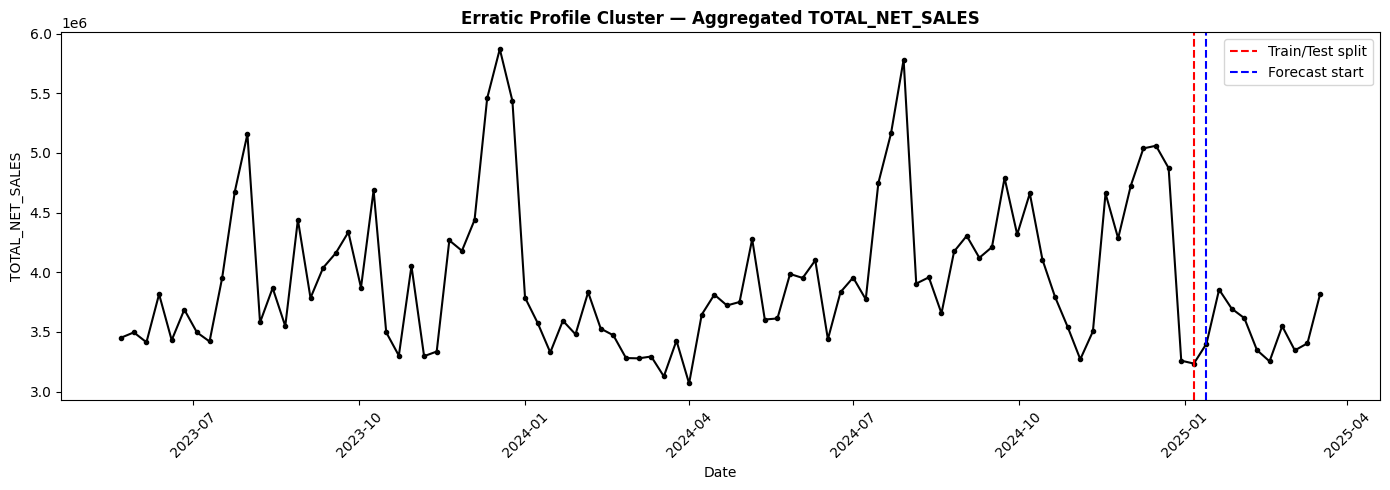

In [5]:
df_plot = (
    df_erratic.groupby(date_var)[y]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_plot[date_var], df_plot[y], color='black', linewidth=1.5, marker='o', markersize=3)
ax.axvline(x=pd.to_datetime(training_end_date), color='red', linestyle='--', label='Train/Test split')
ax.axvline(x=pd.to_datetime(forecast_start_date), color='blue', linestyle='--', label='Forecast start')
ax.set_title(f'Erratic Profile Cluster — Aggregated {y}', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel(y)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Moving Average Models

We define three types of moving average forecasting approaches:

1. **Simple Moving Average (SMA)**: Forecast = mean of last `w` observations
2. **Weighted Moving Average (WMA)**: Forecast = weighted mean with linearly increasing weights (recent observations weigh more)
3. **Exponential Moving Average (EMA)**: Uses exponential decay (`span` parameter)

In [6]:
def forecast_sma(series, window):
    """Simple Moving Average forecast: mean of last `window` values."""
    if len(series) < window:
        return series.mean()
    return series.iloc[-window:].mean()


def forecast_wma(series, window):
    """Weighted Moving Average forecast: linearly increasing weights."""
    if len(series) < window:
        w = np.arange(1, len(series) + 1, dtype=float)
        vals = series.values
    else:
        w = np.arange(1, window + 1, dtype=float)
        vals = series.iloc[-window:].values
    return np.average(vals, weights=w)


def forecast_ema(series, span):
    """Exponential Moving Average forecast: last EMA value."""
    ema = series.ewm(span=span, adjust=False).mean()
    return ema.iloc[-1]


print("Moving average forecast functions defined.")

Moving average forecast functions defined.


# Rolling Evaluation

We perform rolling-origin evaluation on the test window (`training_start_date` to `training_end_date`).

For each evaluation date:
1. Use all data prior to that date as the history
2. Generate a 1-step-ahead forecast using each MA model
3. Compare against the actual value

In [7]:
# Define evaluation dates within the test window
eval_start = pd.to_datetime(training_start_date)
eval_end = pd.to_datetime(training_end_date)

eval_dates = pd.date_range(start=eval_start, end=eval_end, freq=frequency)
# Keep only dates that exist in the data
available_dates = set(df_erratic[date_var].unique())
eval_dates = [d for d in eval_dates if d in available_dates]

print(f"Evaluation dates: {len(eval_dates)} dates from {eval_dates[0].date()} to {eval_dates[-1].date()}")

Evaluation dates: 54 dates from 2024-01-01 to 2025-01-06


In [8]:
results = []

for eval_date in eval_dates:
    for sid in df_erratic[unique_id].unique():
        series_data = df_erratic[
            (df_erratic[unique_id] == sid) & (df_erratic[date_var] <= eval_date)
        ].sort_values(date_var)
        
        # Get actual value at eval_date
        actual_row = series_data[series_data[date_var] == eval_date]
        if actual_row.empty:
            continue
        actual_value = actual_row[y].values[0]
        
        # History is everything before eval_date
        history = series_data[series_data[date_var] < eval_date][y]
        if len(history) < 2:
            continue
        
        row_base = {
            unique_id: sid,
            date_var: eval_date,
            'actual': actual_value,
        }
        
        # SMA forecasts
        for w in MA_WINDOWS:
            row_base[f'SMA_{w}'] = forecast_sma(history, w)
        
        # WMA forecasts
        for w in MA_WINDOWS:
            row_base[f'WMA_{w}'] = forecast_wma(history, w)
        
        # EMA forecasts
        for span in EMA_SPANS:
            row_base[f'EMA_{span}'] = forecast_ema(history, span)
        
        results.append(row_base)

df_results = pd.DataFrame(results)
print(f"Generated {len(df_results)} forecast rows across {df_results[unique_id].nunique()} series")
df_results.head()

Generated 648 forecast rows across 12 series


,STORE_LOCATION_ID,ds,actual,SMA_3,SMA_4,SMA_6,SMA_8,SMA_12,WMA_3,WMA_4,WMA_6,WMA_8,WMA_12,EMA_3,EMA_4,EMA_6,EMA_8,EMA_12
0,9,2024-01-01,333679.812685,525277.040821,499189.010805,461959.085176,430507.892268,407547.637351,522117.220025,512945.936337,489972.753187,467363.977620,437397.033115,502664.554377,492249.123614,471231.156772,454595.702556,432119.257503
1,15,2024-01-01,326905.586644,425552.260104,415374.012681,378671.008785,329634.238898,313663.052881,430881.366015,424678.424681,403514.201542,376840.401081,343600.393734,419436.863000,405944.728939,382152.643284,364575.598433,342255.295450
2,16,2024-01-01,363135.133487,546926.398766,508359.425701,468341.440048,420134.029441,399206.113005,546691.414903,531358.619222,500613.204040,472142.586709,434540.566733,521375.457758,506529.509337,479333.194889,459414.048958,434713.297886
3,17,2024-01-01,338917.486167,478060.323707,455307.508285,419413.403357,389096.481772,367013.954652,476393.203849,467958.925623,446422.832737,424541.085920,395541.455215,460096.257442,449269.979493,428708.912189,412901.057223,392001.145035
4,20,2024-01-01,287040.600399,408111.035064,384555.465244,364063.438895,333143.411395,311950.583160,414330.265718,402420.345528,382951.399703,365254.938303,339189.810130,402089.559861,389780.305099,369450.256897,354673.763555,336082.826452


# Compute Metrics

Compute MAE, RMSE, and WMAPE for each moving average model variant.

In [9]:
def compute_metrics(df_results, actual_col='actual'):
    """Compute MAE, RMSE, WMAPE for all forecast columns."""
    pred_cols = [c for c in df_results.columns if c.startswith(('SMA_', 'WMA_', 'EMA_'))]
    
    metrics_list = []
    actuals = df_results[actual_col].values.astype(float)
    
    for col in pred_cols:
        preds = df_results[col].values.astype(float)
        
        # Remove NaN pairs
        mask = ~(np.isnan(actuals) | np.isnan(preds))
        a = actuals[mask]
        p = preds[mask]
        
        if len(a) == 0:
            continue
        
        mae = mean_absolute_error(a, p)
        rmse = np.sqrt(mean_squared_error(a, p))
        wmape = np.abs(a - p).sum() / np.abs(a).sum() if np.abs(a).sum() > 0 else np.nan
        
        # Parse model type and window
        parts = col.split('_')
        model_type = parts[0]
        window = int(parts[1])
        
        metrics_list.append({
            'model': col,
            'type': model_type,
            'window': window,
            'MAE': mae,
            'RMSE': rmse,
            'WMAPE': wmape,
            'n_predictions': len(a),
        })
    
    return pd.DataFrame(metrics_list).sort_values('MAE')


metrics_df = compute_metrics(df_results)
print("\n=== Model Performance (sorted by MAE) ===")
metrics_df.style.format({
    'MAE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'WMAPE': '{:.4f}',
})


=== Model Performance (sorted by MAE) ===


,model,type,window,MAE,RMSE,WMAPE,n_predictions
10,EMA_3,EMA,3,"42,548.77","55,602.33",0.1297,648
11,EMA_4,EMA,4,"43,496.29","56,219.86",0.1325,648
5,WMA_3,WMA,3,"43,780.42","57,765.33",0.1334,648
12,EMA_6,EMA,6,"44,605.45","56,643.74",0.1359,648
13,EMA_8,EMA,8,"45,108.32","56,719.99",0.1375,648
6,WMA_4,WMA,4,"45,251.75","59,215.94",0.1379,648
14,EMA_12,EMA,12,"45,359.88","56,715.24",0.1382,648
9,WMA_12,WMA,12,"46,799.21","58,167.94",0.1426,648
7,WMA_6,WMA,6,"47,076.60","60,455.92",0.1435,648
4,SMA_12,SMA,12,"47,172.68","58,236.85",0.1437,648


## Metrics Comparison Chart

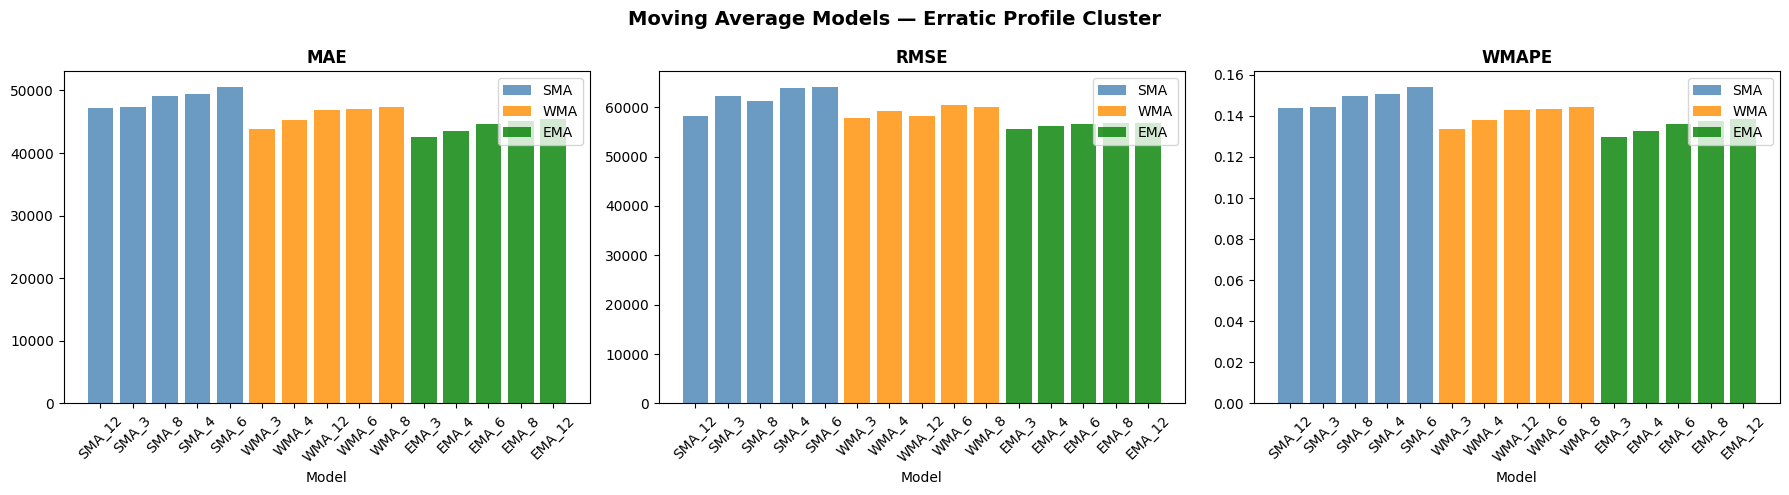

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'WMAPE']):
    # Plot by model type with different colors
    for model_type, color in [('SMA', 'steelblue'), ('WMA', 'darkorange'), ('EMA', 'green')]:
        subset = metrics_df[metrics_df['type'] == model_type]
        ax.bar(
            subset['model'], subset[metric],
            color=color, alpha=0.8, label=model_type
        )
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle(f'Moving Average Models — Erratic Profile Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-Series Metrics

Compute metrics at the individual series level to identify which erratic series benefit most from MA models.

In [11]:
def compute_per_series_metrics(df_results, actual_col='actual'):
    """Compute MAE per series for the best overall model."""
    # Use best model from global metrics
    best_model = metrics_df.iloc[0]['model']
    print(f"Best model (lowest MAE): {best_model}")
    
    per_series = []
    for sid in df_results[unique_id].unique():
        subset = df_results[df_results[unique_id] == sid]
        a = subset[actual_col].values.astype(float)
        p = subset[best_model].values.astype(float)
        
        mask = ~(np.isnan(a) | np.isnan(p))
        a, p = a[mask], p[mask]
        
        if len(a) == 0:
            continue
        
        mae = mean_absolute_error(a, p)
        rmse = np.sqrt(mean_squared_error(a, p))
        wmape = np.abs(a - p).sum() / np.abs(a).sum() if np.abs(a).sum() > 0 else np.nan
        
        per_series.append({
            unique_id: sid,
            'MAE': mae,
            'RMSE': rmse,
            'WMAPE': wmape,
            'n_obs': len(a),
        })
    
    return pd.DataFrame(per_series).sort_values('MAE', ascending=False)


per_series_metrics = compute_per_series_metrics(df_results)
print(f"\nPer-series metrics using best model ({metrics_df.iloc[0]['model']}):")
print(f"  Median MAE: {per_series_metrics['MAE'].median():,.2f}")
print(f"  Mean WMAPE: {per_series_metrics['WMAPE'].mean():.4f}")
per_series_metrics.head(10)

Best model (lowest MAE): EMA_3

Per-series metrics using best model (EMA_3):
  Median MAE: 41,061.87
  Mean WMAPE: 0.1312


,STORE_LOCATION_ID,MAE,RMSE,WMAPE,n_obs
2,16,48701.461298,60777.264603,0.125514,54
9,45,47692.986767,60824.218144,0.168187,54
8,36,46581.160192,60671.092391,0.147879,54
5,24,45524.645543,58784.362815,0.152233,54
10,47,42213.295576,56142.287130,0.116722,54
11,50,41097.977242,54587.767433,0.139268,54
4,20,41025.759788,52799.234245,0.143082,54
0,9,40997.320423,55037.986285,0.111072,54
6,25,40993.492005,53779.896538,0.110137,54
7,31,39988.019515,54547.671179,0.114125,54


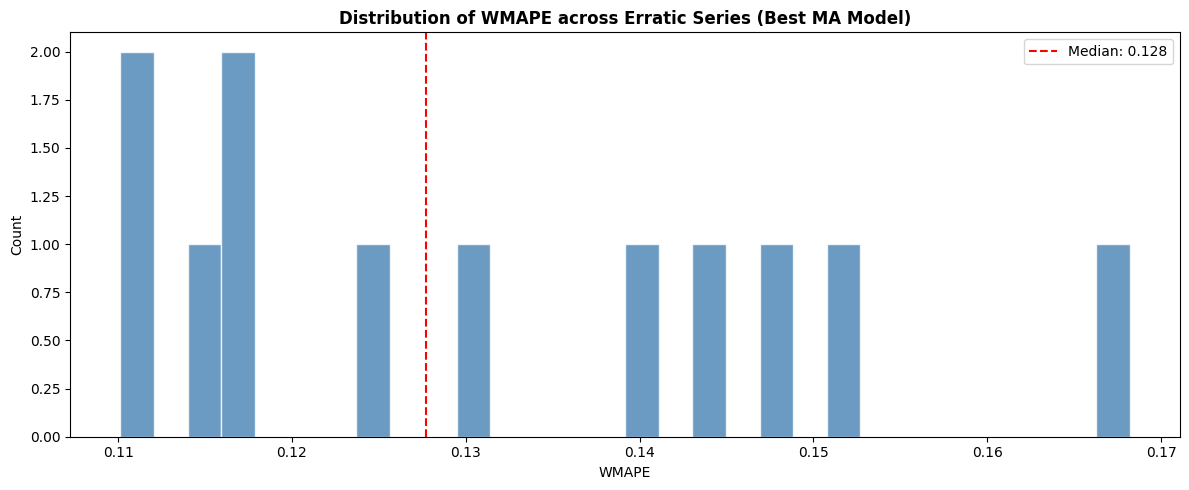

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(per_series_metrics['WMAPE'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(per_series_metrics['WMAPE'].median(), color='red', linestyle='--', label=f"Median: {per_series_metrics['WMAPE'].median():.3f}")
ax.set_title('Distribution of WMAPE across Erratic Series (Best MA Model)', fontsize=12, fontweight='bold')
ax.set_xlabel('WMAPE')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# Forecast Visualization

Plot actual vs. forecast for a sample of erratic series using the best moving average model.

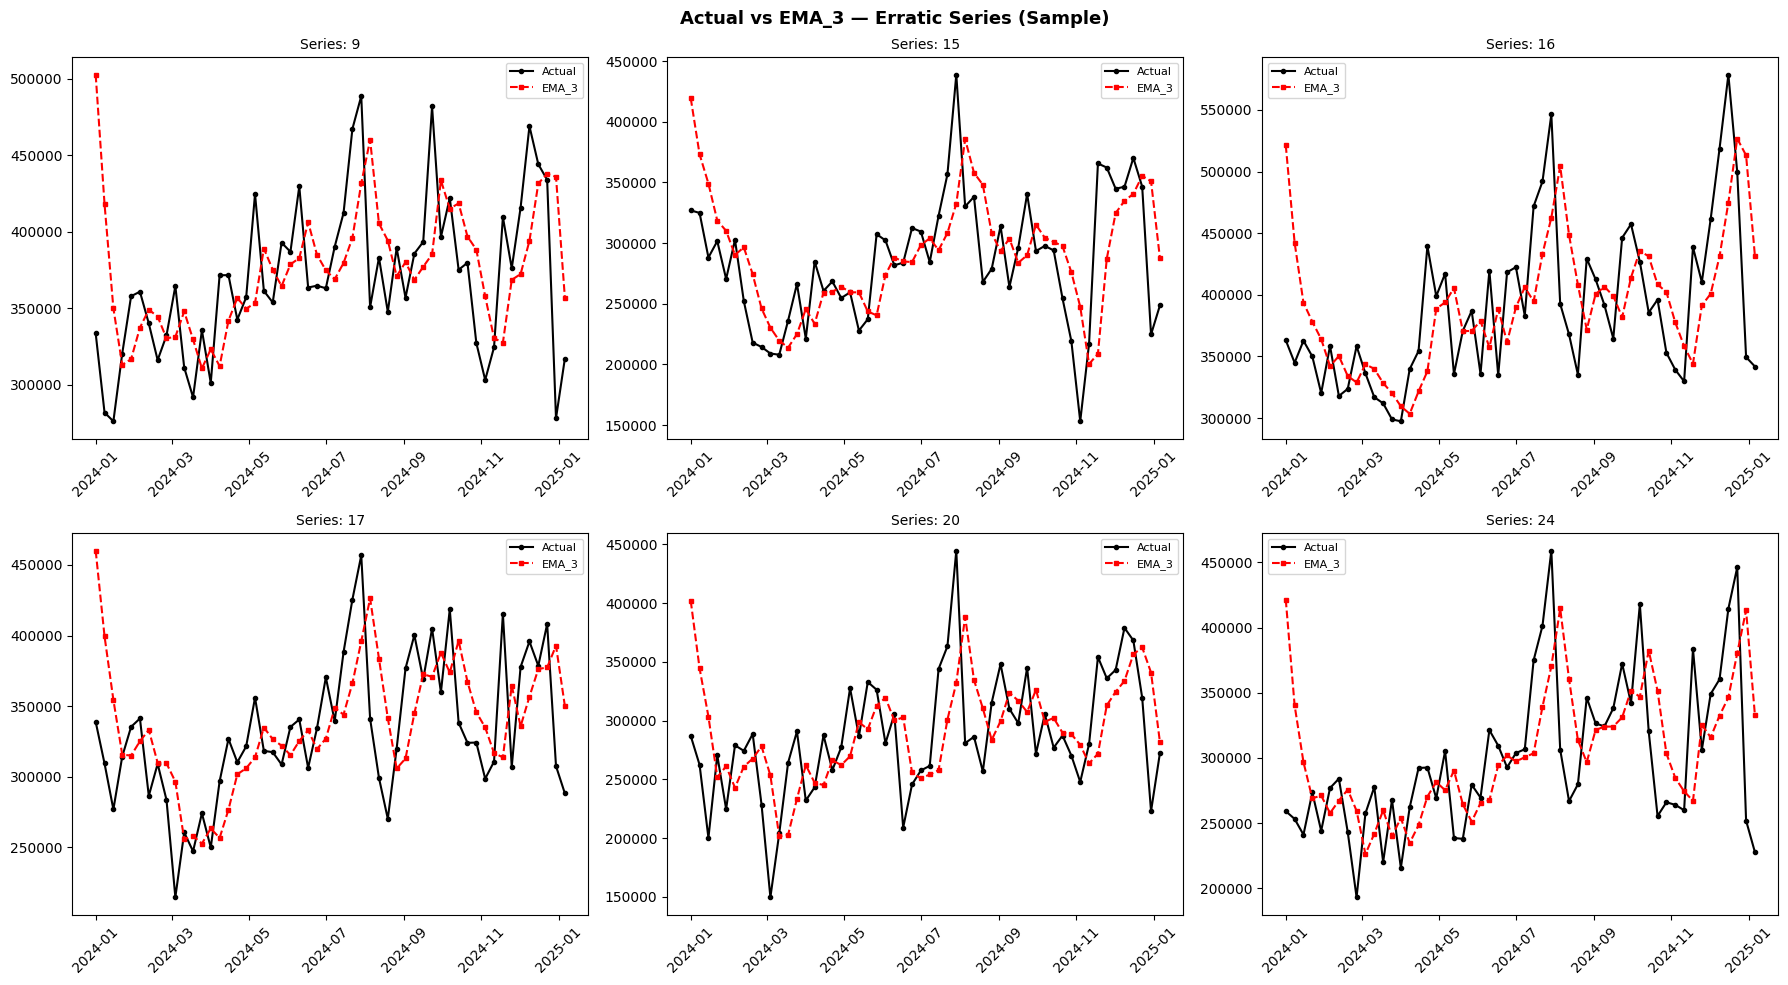

In [13]:
best_model = metrics_df.iloc[0]['model']
sample_ids = df_results[unique_id].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, sid in enumerate(sample_ids):
    if i >= len(axes):
        break
    ax = axes[i]
    subset = df_results[df_results[unique_id] == sid].sort_values(date_var)
    
    ax.plot(subset[date_var], subset['actual'], 'k-o', markersize=3, label='Actual')
    ax.plot(subset[date_var], subset[best_model], 'r--s', markersize=3, label=best_model)
    ax.set_title(f'Series: {sid}', fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Actual vs {best_model} — Erratic Series (Sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Out-of-Sample Forecast

Generate forecasts for the out-of-sample period using the best moving average model.

In [14]:
# Generate OOS forecasts using the best model
best_type = metrics_df.iloc[0]['type']
best_window = int(metrics_df.iloc[0]['window'])

print(f"Best model: {best_model} (type={best_type}, window={best_window})")

oos_start = pd.to_datetime(forecast_start_date)
oos_end = pd.to_datetime(forecast_end_date)
oos_dates = pd.date_range(start=oos_start, end=oos_end, freq=frequency)

oos_forecasts = []

for sid in df_erratic[unique_id].unique():
    # Full history up to training_end_date
    series_hist = df_erratic[
        (df_erratic[unique_id] == sid) & (df_erratic[date_var] <= pd.to_datetime(training_end_date))
    ].sort_values(date_var)[y].values.tolist()
    
    if len(series_hist) < 2:
        continue
    
    for oos_date in oos_dates:
        history = pd.Series(series_hist)
        
        if best_type == 'SMA':
            pred = forecast_sma(history, best_window)
        elif best_type == 'WMA':
            pred = forecast_wma(history, best_window)
        elif best_type == 'EMA':
            pred = forecast_ema(history, best_window)
        else:
            pred = forecast_sma(history, best_window)
        
        oos_forecasts.append({
            unique_id: sid,
            date_var: oos_date,
            'y_hat_ma': pred,
        })
        
        # Append prediction as next "observation" for multi-step recursion
        series_hist.append(pred)

df_oos = pd.DataFrame(oos_forecasts)
print(f"\nOOS forecasts: {len(df_oos)} rows for {df_oos[unique_id].nunique()} series")
print(f"OOS period: {df_oos[date_var].min().date()} to {df_oos[date_var].max().date()}")
df_oos.head()

Best model: EMA_3 (type=EMA, window=3)

OOS forecasts: 228 rows for 12 series
OOS period: 2025-01-13 to 2025-05-19


,STORE_LOCATION_ID,ds,y_hat_ma
0,9,2025-01-13,337156.329148
1,9,2025-01-20,337156.329148
2,9,2025-01-27,337156.329148
3,9,2025-02-03,337156.329148
4,9,2025-02-10,337156.329148


## OOS Metrics (if actuals available)

In [15]:
# Merge with actuals if available in the OOS period
df_oos_eval = df_oos.merge(
    df_erratic[[unique_id, date_var, y]],
    on=[unique_id, date_var],
    how='left'
)

# Filter to rows where actuals exist
df_oos_eval = df_oos_eval.dropna(subset=[y])

if len(df_oos_eval) > 0:
    actuals = df_oos_eval[y].values.astype(float)
    preds = df_oos_eval['y_hat_ma'].values.astype(float)
    
    oos_mae = mean_absolute_error(actuals, preds)
    oos_rmse = np.sqrt(mean_squared_error(actuals, preds))
    oos_wmape = np.abs(actuals - preds).sum() / np.abs(actuals).sum()
    
    print(f"=== Out-of-Sample Metrics ({best_model}) ===")
    print(f"  MAE:   {oos_mae:,.2f}")
    print(f"  RMSE:  {oos_rmse:,.2f}")
    print(f"  WMAPE: {oos_wmape:.4f}")
    print(f"  N predictions: {len(df_oos_eval)}")
else:
    print("No actuals available in the OOS period. Metrics cannot be computed.")

=== Out-of-Sample Metrics (EMA_3) ===
  MAE:   27,788.69
  RMSE:  34,719.85
  WMAPE: 0.0945
  N predictions: 120


# Summary

Print the final summary of results.

In [16]:
print("=" * 60)
print("MOVING AVERAGE MODELS — ERRATIC PROFILE CLUSTER")
print("=" * 60)
print(f"\nSeries count: {n_series}")
print(f"Evaluation window: {training_start_date} to {training_end_date}")
print(f"Forecast window: {forecast_start_date} to {forecast_end_date}")
print(f"\nBest model: {best_model}")
print(f"  - Type: {best_type}")
print(f"  - Window/Span: {best_window}")
print(f"\n--- In-Sample Metrics (Rolling Evaluation) ---")
print(f"  MAE:   {metrics_df.iloc[0]['MAE']:,.2f}")
print(f"  RMSE:  {metrics_df.iloc[0]['RMSE']:,.2f}")
print(f"  WMAPE: {metrics_df.iloc[0]['WMAPE']:.4f}")
print("\n--- All Models Ranked by MAE ---")
print(metrics_df[['model', 'type', 'window', 'MAE', 'RMSE', 'WMAPE']].to_string(index=False))

MOVING AVERAGE MODELS — ERRATIC PROFILE CLUSTER

Series count: 12
Evaluation window: 2024-01-01 to 2025-01-06
Forecast window: 2025-01-13 to 2025-05-20

Best model: EMA_3
  - Type: EMA
  - Window/Span: 3

--- In-Sample Metrics (Rolling Evaluation) ---
  MAE:   42,548.77
  RMSE:  55,602.33
  WMAPE: 0.1297

--- All Models Ranked by MAE ---
 model type  window          MAE         RMSE    WMAPE
 EMA_3  EMA       3 42548.771269 55602.333877 0.129655
 EMA_4  EMA       4 43496.292165 56219.856034 0.132542
 WMA_3  WMA       3 43780.416269 57765.331735 0.133408
 EMA_6  EMA       6 44605.445222 56643.735656 0.135922
 EMA_8  EMA       8 45108.321800 56719.990147 0.137455
 WMA_4  WMA       4 45251.748553 59215.943266 0.137892
EMA_12  EMA      12 45359.877636 56715.235419 0.138221
WMA_12  WMA      12 46799.214297 58167.939384 0.142607
 WMA_6  WMA       6 47076.603057 60455.920815 0.143452
SMA_12  SMA      12 47172.679858 58236.852017 0.143745
 WMA_8  WMA       8 47299.518356 60012.987812 0.144132
